# This notebook walks through a standard LLOWFSC simulation with a monochromatic model. It uses example data to instantiate the model and then demonstrates how LLOWFSC is calibrated and how the loop is closed with dynamic WFE. 

In [1]:

import numpy as np
import scipy
from scipy.optimize import minimize
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits
import copy
import time

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle
from matplotlib.gridspec import GridSpec

import cupy as cp
cp.cuda.Device(0).use()

import lina
from lina.math_module import xp, xcipy
from lina import control_models as cm 
from lina import utils, wfe, dm, efc, pwp

INFO:numexpr.utils:Note: detected 384 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
INFO:numexpr.utils:Note: NumExpr detected 384 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO:numexpr.utils:NumExpr defaulting to 16 threads.
/opt/conda/envs/llowfscSim310/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


# Setup the models for the LLOWFSC images and the coronagraph images used to evaluate contrast performance and estimate residuals from LLOWSFC.

In [2]:
reload(cm)

model_params = {
    'wavelength_c':633e-9,
    'npix':512, 'Ndef':514, 'N_vortex_lres':2048,
    'vortex_hres_sampling':0.025, 'vortex_win_diam':30,
    'vortex_dot_mask_diam_lamDc':0.65,
    'ncamsci':256,
    'camsci_pxscl_lamDc':0.3, 
    'Nact':34,
    'dm_beam_diam':9.2e-3,
    'lyot_pupil_diam':9.2e-3,
    'lyot_stop_diam':8.6e-3,
    'act_spacing':300e-6,
}

M = cm.MODEL(
    **model_params,
)


(514, 514) (514, 514)


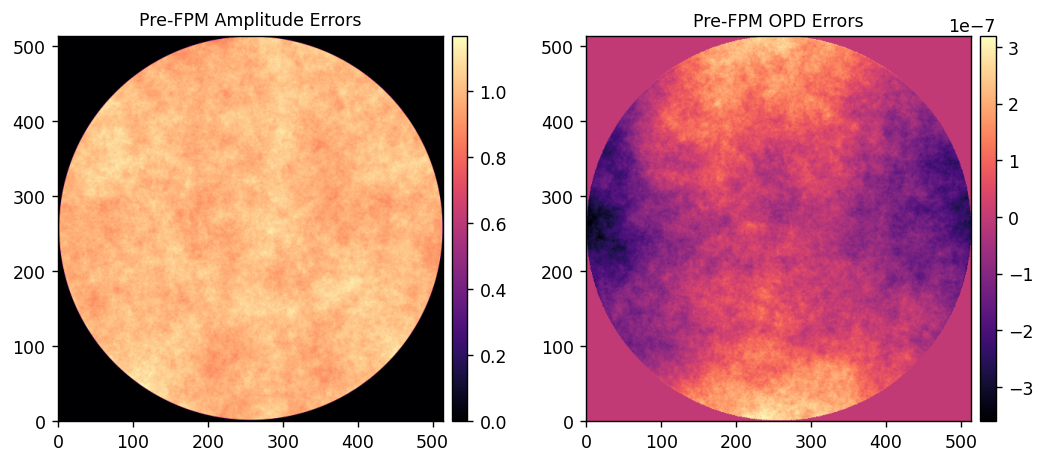

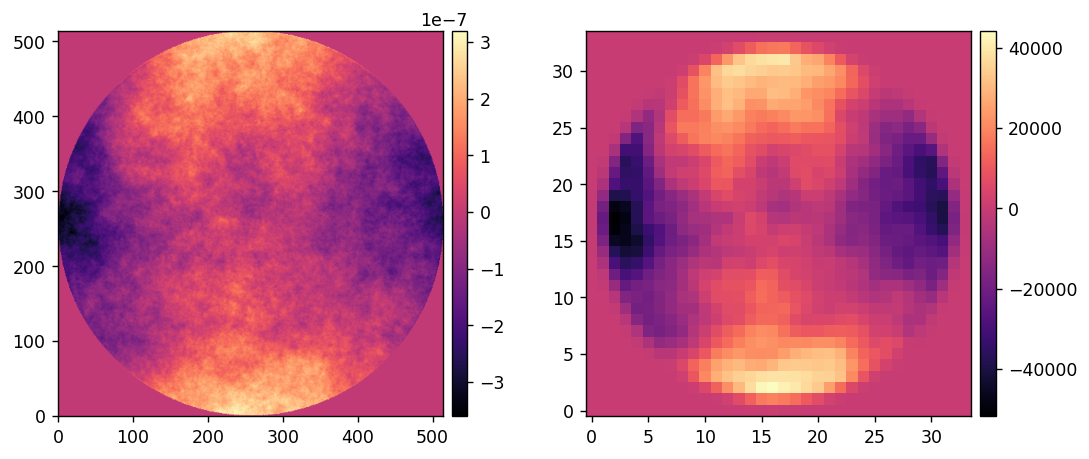

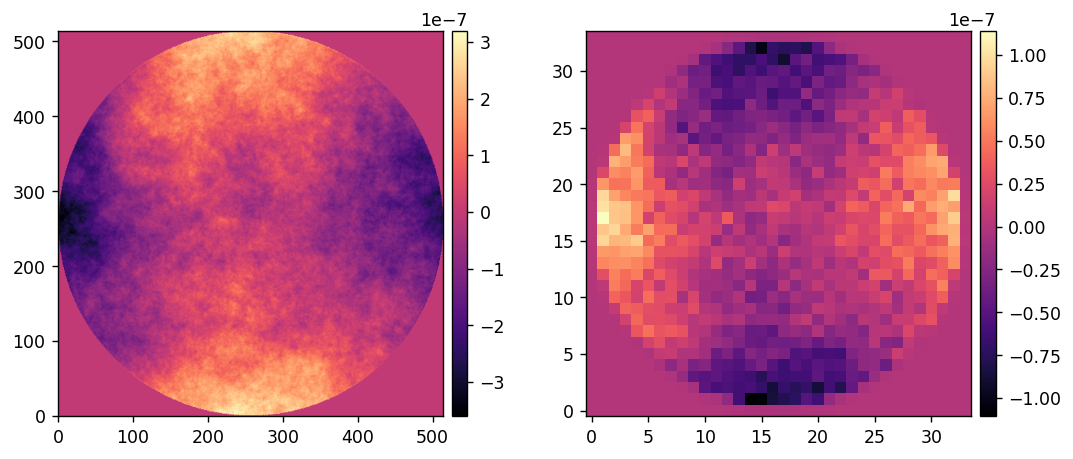

In [3]:
prefpm_slope = 2.5
prefpm_opd_rms = 40*u.nm
prefpm_amp_rms = 0.05
dm_astig_rms = 10e-8
prefpm_wfe_amp, prefpm_wfe_opd = wfe.generate_wfe(
    npix=M.npix, 
    oversample=M.def_oversample,
    wavelength=M.wavelength_c,
    opd_index=prefpm_slope, amp_index=prefpm_slope,
    opd_rms=prefpm_opd_rms, 
    amp_rms=prefpm_amp_rms,
    remove_amp_modes=12,
    remove_opd_modes=3,
    opd_seed=12, 
    amp_seed=123,
)

print(prefpm_wfe_amp.shape, prefpm_wfe_opd.shape)
dm_astig = - dm_astig_rms * wfe.create_zernike_modes(M.APERTURE, nmodes=1, remove_modes=5)[0]
prefpm_wfe_opd += dm_astig
utils.imshow(
    [prefpm_wfe_amp, prefpm_wfe_opd],
    titles=['Pre-FPM Amplitude Errors', 'Pre-FPM OPD Errors'],
)

del_acts = xp.zeros(M.Nacts)
J0, dJ_dA = cm.dm_val_and_grad(
    del_acts, 
    prefpm_wfe_opd, 
    M,
)

dm_grad = xp.zeros((M.Nact, M.Nact))
dm_grad[M.dm_mask] = xp.array(dJ_dA)
utils.imshow([prefpm_wfe_opd, dm_grad])

bfgs_tol = 1e-4
options = {
    'disp':True, 
    # 'maxiter':30,
    # 'maxls':100, # default is 20
    # 'ftol':1e-6, 
    # 'gtol':1e-6,
}
del_acts0 = np.zeros(M.Nacts)
res = minimize(
    cm.dm_val_and_grad, 
    jac=True, 
    x0=del_acts0, 
    args=(prefpm_wfe_opd, M),
    method='L-BFGS-B',
    tol=bfgs_tol,
    options=options,
)

flat_command = xp.zeros((M.Nact, M.Nact))
flat_command[M.dm_mask] = xp.array(res.x)
utils.imshow([prefpm_wfe_opd, flat_command],)

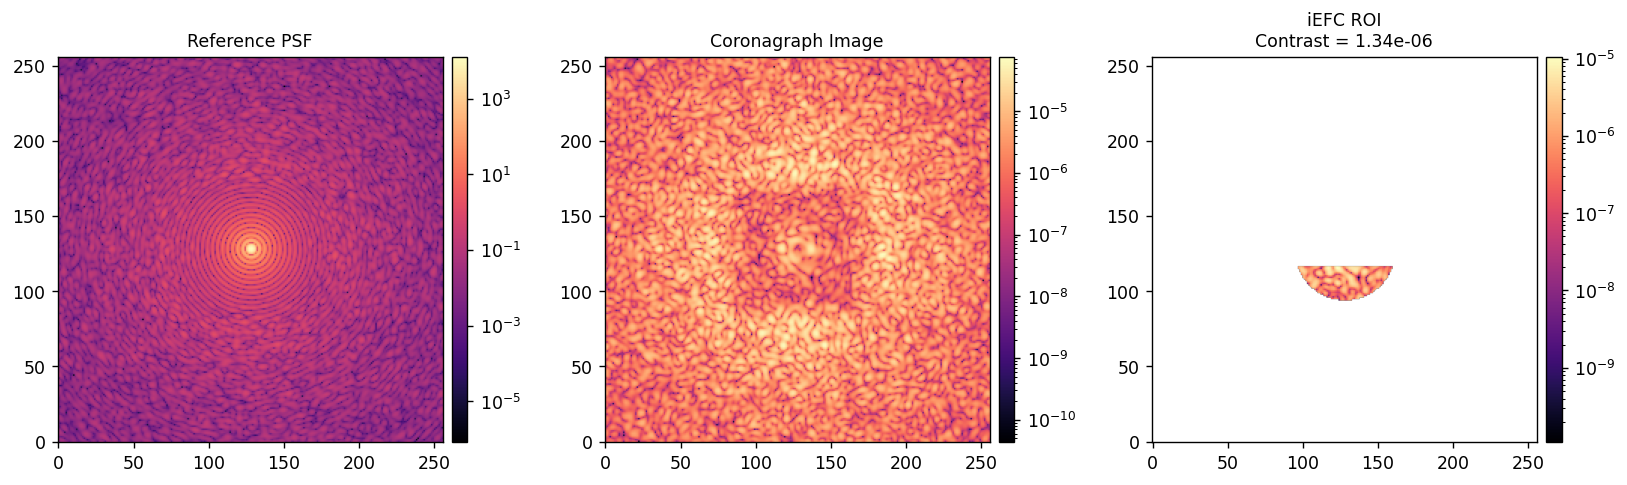

In [4]:
M.PREFPM_AMP = prefpm_wfe_amp
M.PREFPM_OPD = prefpm_wfe_opd
M.dm_commands[0] = flat_command

M.use_vortex = 0
ref_psf = M.snap()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = 1
coro_im = M.snap()

iwa, owa = (3, 10)
wfs_mask = utils.create_annular_focal_plane_mask(
    M.ncamsci, 
    M.camsci_pxscl_lamDc, 
    iwa, 
    owa, 
    edge=iwa, 
    rotation=90, 
    centering='odd',
    # return_np=1,
)
contrast = utils.mean(coro_im, wfs_mask)

utils.imshow(
    [ref_psf, coro_im, coro_im * wfs_mask],
    norms=[LogNorm(), LogNorm(), LogNorm()],
    titles=['Reference PSF', 'Coronagraph Image', f'iEFC ROI\nContrast = {contrast:.2e}']
    # cmaps=['magma'],
)

# Setup the functions needed for EFC

In [7]:
dm_mask = dm.create_mask(Nact=M.Nact)

def take_im_fun(M):
    coro_im = M.snap()
    return coro_im

def set_dm_fun(command, M, channel=1):
    M.dm_commands[channel] = command
    return

def get_dm_fun(M, channel=1):
    return M.dm_commands[channel]

def estimate_ef_fun(M):
    ef = M.forward(xp.sum(M.dm_commands, axis=0)[M.dm_mask])
    return ef

take_im_params = {'M':M}
set_dm_params = {'M':M, 'channel':3}
get_dm_params = {'M':M, 'channel':3}
estimate_ef_params = {'M':M}

# Setup function to estimate the electric field. Since this example uses a model, we directly compute the electric field with no estimation algorithm. 

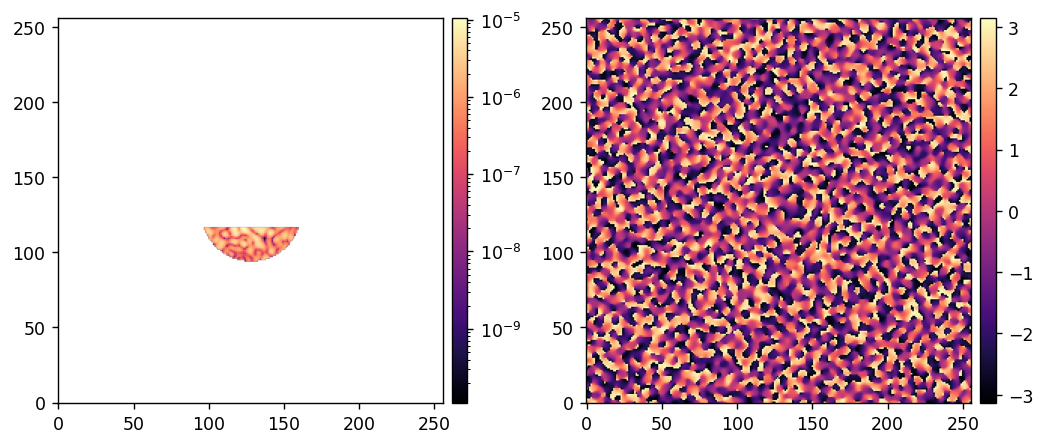

In [8]:

EF = estimate_ef_fun(**estimate_ef_params)
utils.imshow(
    [xp.abs(EF)**2 * wfs_mask, xp.angle(EF)],
    norms=[LogNorm()]
)

# Compute the Jacobian

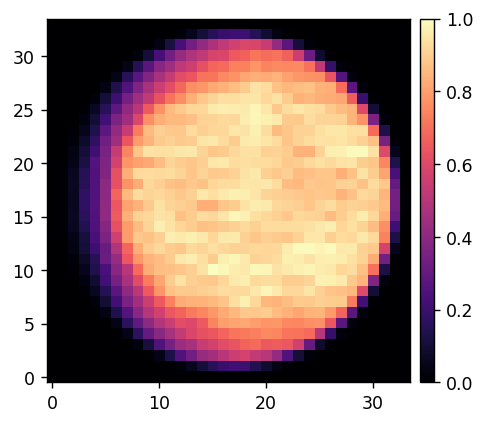

In [9]:
reload(efc)

def compute_ef_fun(command, M, channel=3):

    # M.set_dm(command, channel=channel)
    M.dm_commands[channel] = command
    ef = M.forward(xp.sum(M.dm_commands, axis=0)[M.dm_mask])

    return ef

compute_ef_params = {
    'M':M, 
    'channel':3,
}

response_matrix = efc.calibrate(
    # model, 
    compute_ef_fun,
    compute_ef_params,
    dm_mask,
    wfs_mask, 
    amp=1e-9, 
    current_command=None, 
    plot_response_map=True,
)


In [10]:
cm20 = utils.beta_reg(response_matrix, -2)
cm25 = utils.beta_reg(response_matrix, -2.5, )
cm30 = utils.beta_reg(response_matrix, -3, )
cm35 = utils.beta_reg(response_matrix, -3.5, )
cm40 = utils.beta_reg(response_matrix, -4, )
cm45 = utils.beta_reg(response_matrix, -4.5, )
cm50 = utils.beta_reg(response_matrix, -5, )

# Run EFC.

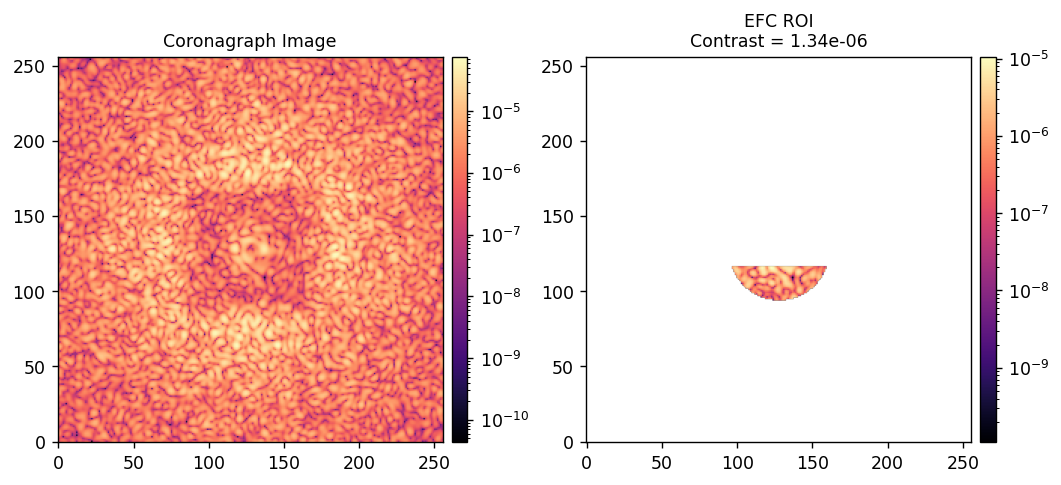

In [11]:
reload(efc)
set_dm_fun(xp.zeros_like(dm_mask), **set_dm_params)
coro_im = take_im_fun(**take_im_params)
contrast = utils.mean(coro_im, wfs_mask)

utils.imshow(
    [coro_im, coro_im * wfs_mask],
    norms=[LogNorm(), LogNorm()],
    titles=['Coronagraph Image', f'EFC ROI\nContrast = {contrast:.2e}'],
)

efc_data = efc.init_data()


Running iteration 7
Ratio of pixels greater than zero versus total pixels: 1063 / 1063 = 1.00


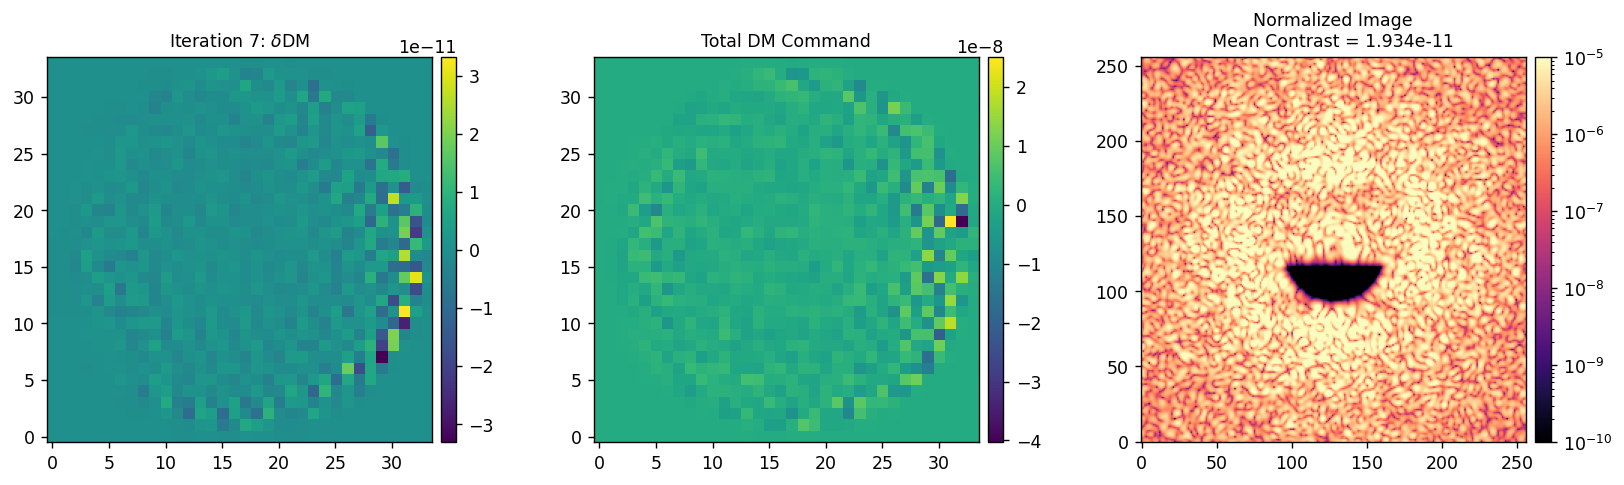

Running iteration 8
Ratio of pixels greater than zero versus total pixels: 1063 / 1063 = 1.00


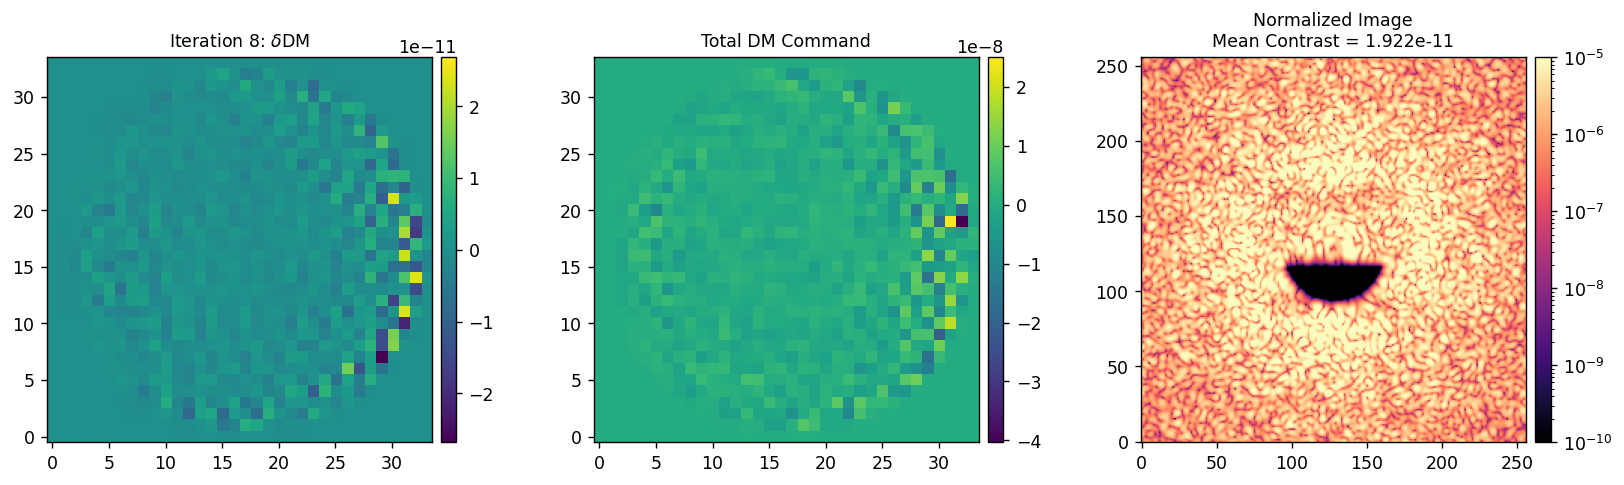

In [15]:
reload(utils)
reload(efc)

data = efc.run(
    efc_data,
    take_im_fun,
    take_im_params,
    set_dm_fun,
    set_dm_params,
    estimate_ef_fun, estimate_ef_params,
    wfs_mask,
    dm_mask,
    cm25,
    # cm50,
    # normalize_metric_fun=None,
    # normalize_metric_params=None,
    num_iterations=2, 
    gain=1.0, 
    leakage=0.0,
    plot_all=True,
    plot_current=True,
)